In [5]:
import os
import sys
import torch
from tqdm import tqdm
from dotenv import load_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

load_dotenv()
sys.path.append(os.getenv("ROOT_PATH"))
import miso_utils.datasets as mud

def show_tensor_image(tensor):
 
    image = tensor.cpu().clone().detach()
    image = image.permute(1, 2, 0)
    
    if image.min() < 0 or image.max() > 1:
        image = (image - image.min()) / (image.max() - image.min())
    
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [6]:
import torch
from PIL import Image
import open_clip

clip_model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

def ClipConcated(images,texts):
    img_emb = clip_model.encode_image(images)
    txt_emb = clip_model.encode_text(texts)
    # Normalize
    img_emb /= img_emb.norm(dim=-1, keepdim=True)
    txt_emb /= txt_emb.norm(dim=-1, keepdim=True)
    return torch.cat((img_emb, txt_emb), dim=1)

val_data = mud.MisoValDataset(os.getenv("VAL_PATH"), image_transform=preprocess )
train_data = mud.MisoTrainDataset(os.getenv("TRAIN_PATH"), image_transform=preprocess)

Files Left: 600it [00:09, 65.20it/s]
Files Left: 9395it [02:43, 57.52it/s]


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusionMatrix(y_true, y_pred):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

## ANN Model

In [9]:
class ANNModel(nn.Module):
    def __init__(self, input_dim=1024):
        super(ANNModel, self).__init__()
        
        # A simple architecture: Input -> Hidden -> Output
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),      # Helps prevent overfitting on smaller datasets
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)     # Single output for binary classification
            # Note: No Sigmoid here if using nn.BCEWithLogitsLoss (recommended)
        )

    def forward(self, x):
        return self.network(x)


In [ ]:
def train_miso_model(ann_model, clip_model, clip_tokenizer, train_loader, val_loader, save_path, epochs=10, lr=1e-4, device="cuda"):
    ann_model.to(device)
    clip_model.to(device)
    clip_model.eval() 
    
    # 1. Change reduction to 'sum'
    criterion = nn.BCEWithLogitsLoss(reduction='sum')
    optimizer = torch.optim.Adam(ann_model.parameters(), lr=lr)
    
    best_val_acc = 0.0
    print(f"Starting training on {device}...")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        ann_model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            images = batch['img'].to(device)
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()

            optimizer.zero_grad()
            with torch.no_grad(), torch.amp.autocast('cuda'):
                features = ClipConcated(images, text_tokens) 
            
            logits = ann_model(features.float()).squeeze()
            loss = criterion(logits, labels) # This is now the sum of losses in the batch
            loss.backward()
            optimizer.step()

            # 2. Track metrics
            train_loss += loss.item()
            train_total += labels.size(0)
            
            preds = (torch.sigmoid(logits) > 0.5).float()
            train_correct += (preds == labels).sum().item()

            # 3. Display Running Average Loss (Total Loss / Total Samples)
            pbar.set_postfix(
                avg_loss=f"{train_loss/train_total:.4f}", 
                acc=f"{100*train_correct/train_total:.2f}%"
            )

        # --- VALIDATION PHASE ---
        ann_model.eval()
        val_loss, val_total, val_correct = 0.0, 0, 0
        
        with torch.no_grad():
            vbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
            for batch in vbar:
                images = batch['img'].to(device)
                text_tokens = clip_tokenizer(batch['transcription']).to(device)
                labels = batch['indian_label'].to(device).float()

                with torch.amp.autocast('cuda'):
                    features = ClipConcated(images, text_tokens)
                
                logits = ann_model(features.float()).squeeze()
                loss = criterion(logits, labels)
                
                val_loss += loss.item()
                val_total += labels.size(0)
                
                preds = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                
                vbar.set_postfix(
                    avg_loss=f"{val_loss/val_total:.4f}", 
                    acc=f"{100*val_correct/val_total:.2f}%"
                )

        epoch_val_acc = 100 * val_correct / val_total
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(ann_model.state_dict(), save_path + 'best_miso_model.pt')
            print(f"--> Saved Best Model (Val Acc: {best_val_acc:.2f}%)")

        print("")

    checkpoint = torch.load(save_path + 'best_miso_model.pt', map_location=device)
    ann_model.load_state_dict(checkpoint)

    y_preds = []
    y_true = []

    with torch.no_grad():
        for batch in val_loader:

            images = batch['img'].to(device)
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()
            with torch.amp.autocast('cuda'):
                features = ClipConcated(images, text_tokens)
            
            logits = ann_model(features.float()).squeeze()
            loss = criterion(logits, labels)
               
            preds = (torch.sigmoid(logits) > 0.5).float()

            y_preds = y_preds + preds.cpu().detach().int().numpy().tolist()
            y_true = y_true + labels.cpu().detach().int().numpy().tolist()

    plot_confusionMatrix(y_true,y_preds)
    return ann_model

Starting training on cuda...


Epoch 1/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 15.85it/s, acc=78.33%, avg_loss=0.4513]


--> Saved Best Model (Val Acc: 78.33%)



Epoch 2/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 15.73it/s, acc=77.83%, avg_loss=0.4424]


Epoch 3/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 15.63it/s, acc=78.00%, avg_loss=0.4421]


...

Epoch 17/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 15.00it/s, acc=76.00%, avg_loss=1.0307]


Epoch 18/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 15.15it/s, acc=77.17%, avg_loss=0.9843]


Epoch 19/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 14.51it/s, acc=75.33%, avg_loss=1.0761]


Epoch 20/20 [Val]: 100%|██████████| 10/10 [00:00<00:00, 14.36it/s, acc=78.17%, avg_loss=1.0964]



[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

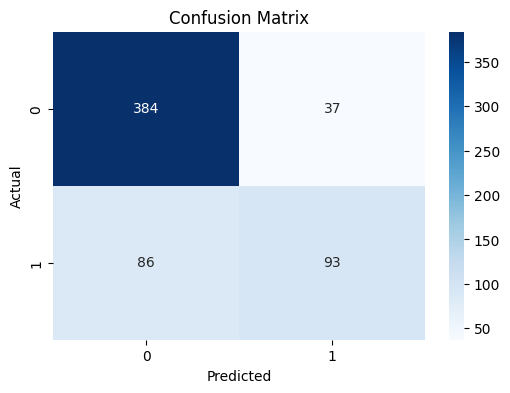

ANNModel(
  (network): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [13]:
ann_model = ANNModel()
train_miso_model(ann_model,clip_model,clip_tokenizer,train_loader,val_loader,save_path=os.getenv("WEIGHTS_PATH") + "/ClipConcatAnn/",epochs = 20,lr = 1e-4 * 5)

## Sklearn Classifiers

In [14]:
from sklearn.utils import all_estimators

# Filter for 'classifier' type estimators
classifiers = all_estimators(type_filter='classifier')

for name, ClassifierClass in classifiers:
    try:
        # Initialize the classifier
        clf = ClassifierClass()
        print(f"Testing: {name}")
        
        # Example: clf.fit(X_train, y_train)
    except Exception as e:
        # Some classifiers require specific parameters during initialization
        print(f"Could not initialize {name}: {e}")

Testing: AdaBoostClassifier
Testing: BaggingClassifier
Testing: BernoulliNB
Testing: CalibratedClassifierCV
Testing: CategoricalNB
Testing: ClassifierChain
Testing: ComplementNB
Testing: DecisionTreeClassifier
Testing: DummyClassifier
Testing: ExtraTreeClassifier
Testing: ExtraTreesClassifier
Could not initialize FixedThresholdClassifier: FixedThresholdClassifier.__init__() missing 1 required positional argument: 'estimator'
Testing: GaussianNB
Testing: GaussianProcessClassifier
Testing: GradientBoostingClassifier
Testing: HistGradientBoostingClassifier
Testing: KNeighborsClassifier
Testing: LabelPropagation
Testing: LabelSpreading
Testing: LinearDiscriminantAnalysis
Testing: LinearSVC
Testing: LogisticRegression
Testing: LogisticRegressionCV
Testing: MLPClassifier
Could not initialize MultiOutputClassifier: MultiOutputClassifier.__init__() missing 1 required positional argument: 'estimator'
Testing: MultinomialNB
Testing: NearestCentroid
Testing: NuSVC
Could not initialize OneVsOneCla

c:\Users\ayush\OneDrive\Desktop\Miso ai\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [15]:
import torch
import numpy as np

def extract_features(loader, device="cuda"):
    X_list = []
    y_list = []
    
    # Ensure models are on the correct device and in eval mode
    # clip_model should be handled inside your ClipConcated or global scope
    ann_model.eval() 
    
    print(f"Extracting features from {len(loader)} batches...")
    
    with torch.no_grad():
        for batch in loader:
            images = batch['img'].to(device)
            # Ensure text_tokens is generated correctly based on your tokenizer setup
            text_tokens = clip_tokenizer(batch['transcription']).to(device)
            labels = batch['indian_label'].to(device).float()
            
            # 1. Extract Multimodal Features
            with torch.amp.autocast('cuda'):
                # Using your ClipConcated function to get the (batch, 1024) features
                features = ClipConcated(images, text_tokens)
            
            # 2. Move to CPU and convert to NumPy
            X_list.append(features.cpu().float().numpy())
            # Ensure labels are (batch_size,) for sklearn compatibility
            y_list.append(labels.cpu().numpy().ravel())
            
    # 3. Stack all batches into final arrays
    X_final = np.vstack(X_list)
    y_final = np.concatenate(y_list)
    
    return X_final, y_final

# --- Usage ---
# Extracting your training and validation sets
X_train, y_train = extract_features(train_loader)
X_val, y_val = extract_features(val_loader)

print(f"Extraction Complete!")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}   | y_val shape: {y_val.shape}")

Extracting features from 147 batches...
Extracting features from 10 batches...
Extraction Complete!
X_train shape: (9395, 1024) | y_train shape: (9395,)
X_val shape: (600, 1024)   | y_val shape: (600,)


In [19]:
from sklearn.utils import all_estimators
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import warnings

# Suppress warnings from models that don't converge or have zero-division in metrics
warnings.filterwarnings('ignore')

print(f"{'Classifier':<25} | {'Acc':<6} | {'Prec':<6} | {'Rec':<6} | {'F1':<6}")
print("-" * 65)
# 2. Setup iteration
classifiers = all_estimators(type_filter='classifier')
results = []

for name, ClassifierClass in classifiers:
    # Skip meta-classifiers and known incompatible models
    if name in ['OutputCodeClassifier', 'OneVsOneClassifier', 'OneVsRestClassifier', 
                'VotingClassifier', 'StackingClassifier', 'ClassifierChain', 'NuSVC']:
        continue
        
    try:
        clf = ClassifierClass()
        clf.fit(X_train, y_train)
        
        preds = clf.predict(X_val)
        
        # Calculate metrics (using 'binary' since your labels are likely 0/1)
        acc = accuracy_score(y_val, preds)
        prec = precision_score(y_val, preds, average='binary')
        rec = recall_score(y_val, preds, average='binary')
        f1 = f1_score(y_val, preds, average='binary')
        
        print(f"{name:<25} | {acc:.3f} | {prec:.3f} | {rec:.3f} | {f1:.3f}")
        
        results.append({
            "Model": name, 
            "Accuracy": acc, 
            "Precision": prec, 
            "Recall": rec, 
            "F1-Score": f1
        })
        
    except Exception:
        # Skip models that require specific parameters or fail on (n, 1024)
        continue


# 3. Final Summary Table
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\nSorted by F1-Score (Top 10):")
print(df_results.head(10).to_string(index=False))

Classifier                | Acc    | Prec   | Rec    | F1    
-----------------------------------------------------------------
AdaBoostClassifier        | 0.760 | 0.636 | 0.458 | 0.532
BaggingClassifier         | 0.748 | 0.671 | 0.307 | 0.421
BernoulliNB               | 0.755 | 0.577 | 0.670 | 0.620
CalibratedClassifierCV    | 0.790 | 0.715 | 0.492 | 0.583
CategoricalNB             | 0.702 | 0.000 | 0.000 | 0.000
DecisionTreeClassifier    | 0.680 | 0.464 | 0.464 | 0.464
DummyClassifier           | 0.702 | 0.000 | 0.000 | 0.000
ExtraTreeClassifier       | 0.602 | 0.351 | 0.397 | 0.373
ExtraTreesClassifier      | 0.738 | 0.824 | 0.156 | 0.263
GaussianNB                | 0.758 | 0.582 | 0.676 | 0.625
GaussianProcessClassifier | 0.795 | 0.741 | 0.480 | 0.583
GradientBoostingClassifier | 0.768 | 0.669 | 0.441 | 0.532
HistGradientBoostingClassifier | 0.778 | 0.692 | 0.464 | 0.555
KNeighborsClassifier      | 0.752 | 0.585 | 0.575 | 0.580
LabelPropagation          | 0.750 | 0.579 | 0.592 | 0.